Using device: cpu
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_0.pth
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_1.pth
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_2.pth
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_3.pth
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_4.pth
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_5.pth
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_6.pth
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_7.pth
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_8.pth
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_9.pth
Using 78 profiles


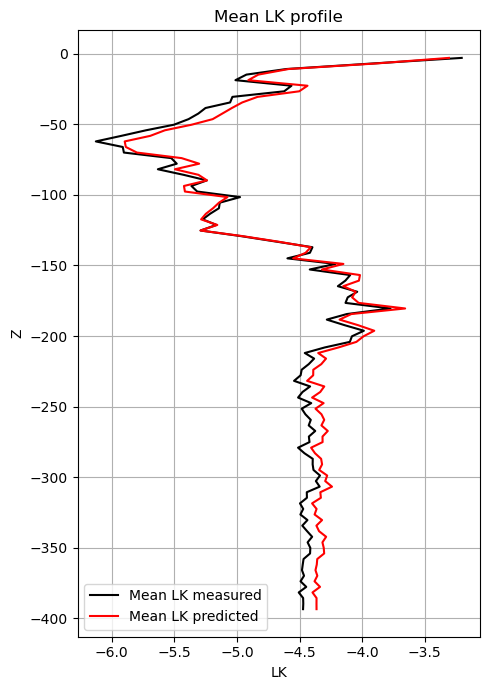

In [9]:
folder_test = "/home/ole-alexander-wallner/Scientific Machine Learning/Scientific Machine Learning/data/profiles_geomar"  # specify the test profile folder here
profile_test = "*.csv"  # specify the test profile(s) here

#profile name is profile test without GEO_ and without _*.csv
profile_name = profile_test.replace("GEO_","").replace("_*.csv","")

import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from iostats_py_explained import getStats
from NNarch import ResMLP

# =====================================================
# CONFIGURATION – ADAPT TO YOUR FILE LOCATIONS
# =====================================================

# Folder containing GEO_AT08_4_001.csv ... GEO_AT08_4_078.csv
# CRUISE_DIR = "/Users/axeanddeer/Downloads/Scientific Machine Learning/data/profiles_geomar"

CRUISE_DIR = folder_test #Validation profile

# Pattern for cruise files (001–078)
CRUISE_PATTERN = profile_test

# Normalization stats (same as training)
MEAN_CSV = "mean_all_data.csv"
STD_CSV  = "std_all_data.csv"
ZMIN = -1062.0

# ResMLP ensemble directory
MODEL_DIR = "./10fold_ALL DATA WITH GEOMAR"



# Columns
PRED_VARS = ['hab', 'S', 'T', 'dSdz', 'dTdz', 'LN2', 'N2']
FEATURE_ORDER = ['hab', 'S', 'T', 'dSdz', 'dTdz', 'LN2', 'N2', 'lat', 'Z']
TARGET_VARS = ['LK', 'Leps']


# =====================================================
# PREPROCESSING (MATCHES TRAINING)
# =====================================================

def preprocess_df(df, meandict, stddict, zmin=ZMIN):
    if 'LN2' not in df.columns:
        df['LN2'] = np.log10(df['N2'])

    df_norm = df.copy()
    for var in PRED_VARS:
        df_norm[var] = (df[var] - meandict[var]) / stddict[var]

    df_norm['lat'] = df['lat'] / 90.0
    df_norm['Z'] = df['Z'] / zmin

    X = df_norm[FEATURE_ORDER].values.astype(float)
    return X


# =====================================================
# LOAD ENSEMBLE
# =====================================================

def load_resmlp_ensemble(model_dir=MODEL_DIR,
                         numLayers=3, nhidden=120,
                         ninp=9, nout=2,
                         lr_max=3.5e-3, batch_size=1000):

    device = torch.device(
        "cuda" if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available()
        else "cpu"
    )
    print("Using device:", device)

    models = []
    for fold in range(10):
        fname = f"ResMLP_{numLayers}_{nhidden}_{lr_max}_{batch_size}_{fold}.pth"
        fpath = os.path.join(model_dir, fname)
        if not os.path.exists(fpath):
            raise FileNotFoundError(f"Missing model file: {fpath}")

        model = ResMLP(numLayers=numLayers,
                       nhidden=nhidden,
                       ninp=ninp,
                       nout=nout).to(device)
        state = torch.load(fpath, map_location=device)
        model.load_state_dict(state, strict=True)
        model.eval()
        models.append(model)
        print("Loaded", fpath)

    return models, device


def predict_ensemble(models, device, X):
    x = torch.tensor(X, dtype=torch.float32).to(device)
    with torch.no_grad():
        preds = []
        for m in models:
            preds.append(m(x).cpu().numpy())
        preds = np.stack(preds, axis=0)
        y_mean = preds.mean(axis=0)
    return y_mean


def denormalize_targets(y_norm, meandict, stddict):
    LK = y_norm[:, 0] * stddict['LK'] + meandict['LK']
    Leps = y_norm[:, 1] * stddict['Leps'] + meandict['Leps']
    return np.stack([LK, Leps], axis=1)


# =====================================================
# BUILD MEAN MEASURED AND PREDICTED PROFILES
# =====================================================

def main():
    # stats and ensemble
    meandict, stddict = getStats(MEAN_CSV, STD_CSV)
    models, device = load_resmlp_ensemble()

    # collect all cruise files 001–078
    pattern = os.path.join(CRUISE_DIR, CRUISE_PATTERN)
    all_files = sorted(glob.glob(pattern))
    # restrict to first 78 if directory has more
    cruise_files = all_files[:78]

    if not cruise_files:
        raise RuntimeError("No cruise files found with pattern " + pattern)

    print("Using", len(cruise_files), "profiles")

    # storage for all profiles
    all_Z = []
    all_meas = []
    all_pred = []

    for f in cruise_files:
        df = pd.read_csv(f)

        # skip empty profiles
        if len(df) == 0:
            continue

        # preprocess and predict
        X = preprocess_df(df, meandict, stddict, zmin=ZMIN)
        y_norm = predict_ensemble(models, device, X)
        y_pred = denormalize_targets(y_norm, meandict, stddict)

        # measured (physical) LK / Leps assumed present
        y_meas = df[TARGET_VARS].values.astype(float)
        Z_raw = df['Z'].values.astype(float)

        all_Z.append(Z_raw)
        all_meas.append(y_meas)
        all_pred.append(y_pred)

    # -------------------------------------------------
    # To form mean vertical profiles, interpolate each
    # profile onto a common Z grid, then average.
    # -------------------------------------------------
    # build common Z grid from min/max of all profiles
    Z_concat = np.concatenate(all_Z)
    z_min, z_max = Z_concat.min(), Z_concat.max()
    nz = 100
    Z_grid = np.linspace(z_min, z_max, nz)

    meas_grid_acc = []
    pred_grid_acc = []

    for Z_raw, meas, pred in zip(all_Z, all_meas, all_pred):
        # sort by Z to avoid issues
        idx = np.argsort(Z_raw)
        z_sorted = Z_raw[idx]
        meas_sorted = meas[idx]
        pred_sorted = pred[idx]

        meas_LK = np.interp(Z_grid, z_sorted, meas_sorted[:, 0])
        pred_LK = np.interp(Z_grid, z_sorted, pred_sorted[:, 0])

        meas_grid_acc.append(meas_LK)
        pred_grid_acc.append(pred_LK)

    meas_grid_acc = np.stack(meas_grid_acc, axis=0)   # (n_profiles, nz)
    pred_grid_acc = np.stack(pred_grid_acc, axis=0)

    mean_meas_profile = meas_grid_acc.mean(axis=0)
    mean_pred_profile = pred_grid_acc.mean(axis=0)

    # =================================================
    # PLOT MEAN MEASURED VS PREDICTED
    # =================================================
    plt.figure(figsize=(5, 7))
    plt.plot(mean_meas_profile, Z_grid, 'k-', label='Mean LK measured')
    plt.plot(mean_pred_profile, Z_grid, 'r-', label='Mean LK predicted')
    plt.gca().invert_yaxis()
    plt.xlabel('LK')
    plt.ylabel('Z')
    plt.legend()
    plt.gca().invert_yaxis()
    plt.grid(True)
    plt.title('Mean LK profile')
    plt.tight_layout()
    plt.show()  

    return mean_pred_profile


if __name__ == "__main__":
    mean_pred_NN = main()


Using device: cpu
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_0.pth
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_1.pth
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_2.pth
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_3.pth
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_4.pth
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_5.pth
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_6.pth
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_7.pth
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_8.pth
Loaded ./10fold_ALL DATA WITH GEOMAR/ResMLP_3_120_0.0035_1000_9.pth
Found 3847 files
Saved: ./predictions_out/global_stats.csv
Saved: ./predictions_out/per_profile_stats.csv
Saved: ./predictions_out/mean_vertical_profiles.csv


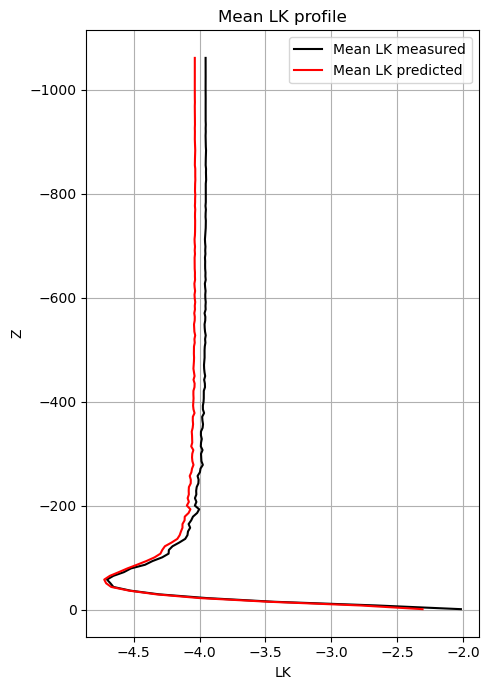

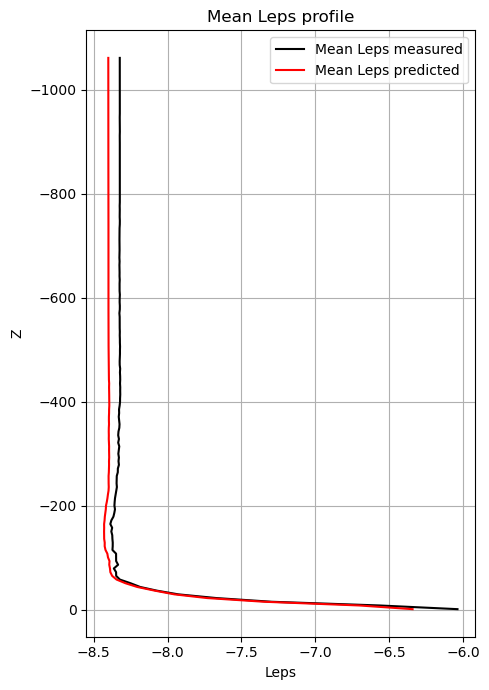

In [11]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from iostats_py_explained import getStats
from NNarch import ResMLP

# =====================================================
# CONFIGURATION – ADAPT TO YOUR FILE LOCATIONS
# =====================================================
folder_test = "/home/ole-alexander-wallner/Scientific Machine Learning/Scientific Machine Learning/data/profiles_geomar"
profile_test = "GEO_*.csv"  # predict ALL profiles in folder

CRUISE_DIR = folder_test
CRUISE_PATTERN = profile_test

MEAN_CSV = "mean_all_data.csv"
STD_CSV  = "std_all_data.csv"
ZMIN = -1062.0

MODEL_DIR = "./10fold_ALL DATA WITH GEOMAR"

PRED_VARS = ['hab', 'S', 'T', 'dSdz', 'dTdz', 'LN2', 'N2']
FEATURE_ORDER = ['hab', 'S', 'T', 'dSdz', 'dTdz', 'LN2', 'N2', 'lat', 'Z']
TARGET_VARS = ['LK', 'Leps']  # must exist in CSVs for metrics

# outputs
OUT_DIR = "./predictions_out"
os.makedirs(OUT_DIR, exist_ok=True)


# =====================================================
# PREPROCESSING (MATCHES TRAINING)
# =====================================================
def preprocess_df(df, meandict, stddict, zmin=ZMIN):
    df = df.copy()

    if 'LN2' not in df.columns:
        # avoid log of non-positive
        if (df['N2'] <= 0).any():
            df.loc[df['N2'] <= 0, 'N2'] = np.nan
        df['LN2'] = np.log10(df['N2'])

    # drop rows with missing required inputs
    req = set(PRED_VARS + ['lat', 'Z'])
    df = df.dropna(subset=list(req))

    df_norm = df.copy()
    for var in PRED_VARS:
        df_norm[var] = (df[var] - meandict[var]) / stddict[var]

    df_norm['lat'] = df['lat'] / 90.0
    df_norm['Z'] = df['Z'] / zmin

    X = df_norm[FEATURE_ORDER].values.astype(np.float32)
    return df, X  # return filtered raw df + X


# =====================================================
# LOAD ENSEMBLE
# =====================================================
def load_resmlp_ensemble(model_dir=MODEL_DIR,
                         numLayers=3, nhidden=120,
                         ninp=9, nout=2,
                         lr_max=3.5e-3, batch_size=1000):

    device = torch.device(
        "cuda" if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available()
        else "cpu"
    )
    print("Using device:", device)

    models = []
    for fold in range(10):
        fname = f"ResMLP_{numLayers}_{nhidden}_{lr_max}_{batch_size}_{fold}.pth"
        fpath = os.path.join(model_dir, fname)
        if not os.path.exists(fpath):
            raise FileNotFoundError(f"Missing model file: {fpath}")

        model = ResMLP(numLayers=numLayers, nhidden=nhidden, ninp=ninp, nout=nout).to(device)
        state = torch.load(fpath, map_location=device)
        model.load_state_dict(state, strict=True)
        model.eval()
        models.append(model)
        print("Loaded", fpath)

    return models, device


def predict_ensemble(models, device, X):
    x = torch.tensor(X, dtype=torch.float32, device=device)
    with torch.no_grad():
        preds = []
        for m in models:
            preds.append(m(x).cpu().numpy())
        preds = np.stack(preds, axis=0)      # (n_models, n_samples, 2)
        y_mean = preds.mean(axis=0)          # (n_samples, 2)
    return y_mean


def denormalize_targets(y_norm, meandict, stddict):
    LK = y_norm[:, 0] * stddict['LK'] + meandict['LK']
    Leps = y_norm[:, 1] * stddict['Leps'] + meandict['Leps']
    return np.stack([LK, Leps], axis=1)


# =====================================================
# METRICS
# =====================================================
def rmse(y, yhat):
    return float(np.sqrt(np.nanmean((yhat - y) ** 2)))

def mae(y, yhat):
    return float(np.nanmean(np.abs(yhat - y)))

def bias(y, yhat):
    return float(np.nanmean(yhat - y))

def r2(y, yhat):
    y = np.asarray(y); yhat = np.asarray(yhat)
    m = np.isfinite(y) & np.isfinite(yhat)
    if m.sum() < 3:
        return np.nan
    ss_res = np.sum((yhat[m] - y[m])**2)
    ss_tot = np.sum((y[m] - np.mean(y[m]))**2)
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan


# =====================================================
# MAIN: PREDICT ALL + GENERAL STATS
# =====================================================
def main():
    meandict, stddict = getStats(MEAN_CSV, STD_CSV)
    models, device = load_resmlp_ensemble()

    pattern = os.path.join(CRUISE_DIR, CRUISE_PATTERN)
    cruise_files = sorted(glob.glob(pattern))
    if not cruise_files:
        raise RuntimeError("No cruise files found with pattern " + pattern)

    print("Found", len(cruise_files), "files")

    # global accumulators (all samples across all profiles)
    y_meas_all = []
    y_pred_all = []

    # for mean vertical profiles (interpolation)
    all_Z = []
    all_meas = []
    all_pred = []

    # per-profile metrics
    per_profile_rows = []

    for f in cruise_files:
        df0 = pd.read_csv(f)
        if len(df0) == 0:
            continue

        df, X = preprocess_df(df0, meandict, stddict, zmin=ZMIN)
        if len(df) == 0:
            continue

        y_norm = predict_ensemble(models, device, X)
        y_pred = denormalize_targets(y_norm, meandict, stddict)

        out_df = df.copy()
        out_df["LK_pred"] = y_pred[:, 0]
        out_df["Leps_pred"] = y_pred[:, 1]

        base = os.path.splitext(os.path.basename(f))[0]
        out_path = os.path.join(OUT_DIR, f"{base}_pred.csv")
        out_df.to_csv(out_path, index=False)

        # if measured targets exist -> compute metrics and store for global stats
        if all(v in out_df.columns for v in TARGET_VARS):
            y_meas = out_df[TARGET_VARS].values.astype(float)
            y_meas_all.append(y_meas)
            y_pred_all.append(y_pred)

            # per profile metrics
            row = {
                "profile": base,
                "n": len(out_df),
                "LK_rmse": rmse(y_meas[:, 0], y_pred[:, 0]),
                "LK_mae": mae(y_meas[:, 0], y_pred[:, 0]),
                "LK_bias": bias(y_meas[:, 0], y_pred[:, 0]),
                "LK_r2": r2(y_meas[:, 0], y_pred[:, 0]),
                "Leps_rmse": rmse(y_meas[:, 1], y_pred[:, 1]),
                "Leps_mae": mae(y_meas[:, 1], y_pred[:, 1]),
                "Leps_bias": bias(y_meas[:, 1], y_pred[:, 1]),
                "Leps_r2": r2(y_meas[:, 1], y_pred[:, 1]),
            }
            per_profile_rows.append(row)

            # save for mean vertical profiles
            if "Z" in out_df.columns:
                Z_raw = out_df["Z"].values.astype(float)
                all_Z.append(Z_raw)
                all_meas.append(y_meas)
                all_pred.append(y_pred)

    # -------------------------
    # GENERAL (GLOBAL) STATS
    # -------------------------
    if len(y_meas_all) == 0:
        print("No measured targets found; wrote *_pred.csv files but cannot compute stats.")
        return

    y_meas_all = np.vstack(y_meas_all)
    y_pred_all = np.vstack(y_pred_all)

    global_stats = {
        "n_samples": int(y_meas_all.shape[0]),
        "LK_rmse": rmse(y_meas_all[:, 0], y_pred_all[:, 0]),
        "LK_mae": mae(y_meas_all[:, 0], y_pred_all[:, 0]),
        "LK_bias": bias(y_meas_all[:, 0], y_pred_all[:, 0]),
        "LK_r2": r2(y_meas_all[:, 0], y_pred_all[:, 0]),
        "Leps_rmse": rmse(y_meas_all[:, 1], y_pred_all[:, 1]),
        "Leps_mae": mae(y_meas_all[:, 1], y_pred_all[:, 1]),
        "Leps_bias": bias(y_meas_all[:, 1], y_pred_all[:, 1]),
        "Leps_r2": r2(y_meas_all[:, 1], y_pred_all[:, 1]),
    }

    pd.DataFrame([global_stats]).to_csv(os.path.join(OUT_DIR, "global_stats.csv"), index=False)
    pd.DataFrame(per_profile_rows).to_csv(os.path.join(OUT_DIR, "per_profile_stats.csv"), index=False)

    print("Saved:", os.path.join(OUT_DIR, "global_stats.csv"))
    print("Saved:", os.path.join(OUT_DIR, "per_profile_stats.csv"))

    # -------------------------
    # MEAN VERTICAL PROFILES
    # -------------------------
    if len(all_Z) >= 2:
        Z_concat = np.concatenate(all_Z)
        z_min, z_max = float(np.nanmin(Z_concat)), float(np.nanmax(Z_concat))
        nz = 150
        Z_grid = np.linspace(z_min, z_max, nz)

        # interpolate LK and Leps
        meas_LK_acc, pred_LK_acc = [], []
        meas_Leps_acc, pred_Leps_acc = [], []

        for Z_raw, meas, pred in zip(all_Z, all_meas, all_pred):
            m = np.isfinite(Z_raw) & np.isfinite(meas[:, 0]) & np.isfinite(pred[:, 0])
            if m.sum() < 2:
                continue
            idx = np.argsort(Z_raw[m])
            z = Z_raw[m][idx]
            meas_s = meas[m][idx]
            pred_s = pred[m][idx]

            meas_LK_acc.append(np.interp(Z_grid, z, meas_s[:, 0]))
            pred_LK_acc.append(np.interp(Z_grid, z, pred_s[:, 0]))
            meas_Leps_acc.append(np.interp(Z_grid, z, meas_s[:, 1]))
            pred_Leps_acc.append(np.interp(Z_grid, z, pred_s[:, 1]))

        meas_LK_acc = np.stack(meas_LK_acc, axis=0)
        pred_LK_acc = np.stack(pred_LK_acc, axis=0)
        meas_Leps_acc = np.stack(meas_Leps_acc, axis=0)
        pred_Leps_acc = np.stack(pred_Leps_acc, axis=0)

        mean_profiles = pd.DataFrame({
            "Z_grid": Z_grid,
            "LK_meas_mean": meas_LK_acc.mean(axis=0),
            "LK_pred_mean": pred_LK_acc.mean(axis=0),
            "Leps_meas_mean": meas_Leps_acc.mean(axis=0),
            "Leps_pred_mean": pred_Leps_acc.mean(axis=0),
            "LK_meas_std": meas_LK_acc.std(axis=0),
            "LK_pred_std": pred_LK_acc.std(axis=0),
            "Leps_meas_std": meas_Leps_acc.std(axis=0),
            "Leps_pred_std": pred_Leps_acc.std(axis=0),
        })
        mean_profiles.to_csv(os.path.join(OUT_DIR, "mean_vertical_profiles.csv"), index=False)
        print("Saved:", os.path.join(OUT_DIR, "mean_vertical_profiles.csv"))

        # plots
        plt.figure(figsize=(5, 7))
        plt.plot(mean_profiles["LK_meas_mean"], mean_profiles["Z_grid"], "k-", label="Mean LK measured")
        plt.plot(mean_profiles["LK_pred_mean"], mean_profiles["Z_grid"], "r-", label="Mean LK predicted")
        plt.gca().invert_yaxis()
        plt.xlabel("LK")
        plt.ylabel("Z")
        plt.grid(True)
        plt.legend()
        plt.title("Mean LK profile")
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, "mean_LK_profile.png"), dpi=200)
        plt.show()

        plt.figure(figsize=(5, 7))
        plt.plot(mean_profiles["Leps_meas_mean"], mean_profiles["Z_grid"], "k-", label="Mean Leps measured")
        plt.plot(mean_profiles["Leps_pred_mean"], mean_profiles["Z_grid"], "r-", label="Mean Leps predicted")
        plt.gca().invert_yaxis()
        plt.xlabel("Leps")
        plt.ylabel("Z")
        plt.grid(True)
        plt.legend()
        plt.title("Mean Leps profile")
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, "mean_Leps_profile.png"), dpi=200)
        plt.show()


if __name__ == "__main__":
    main()


ResMLP Ensemble (advanced model):
LK RMSE/MAE/R²: 0.572 / 0.396 / 0.799
Leps RMSE/MAE/R²: 0.572 / 0.397 / 0.653

Per-profile avg LK RMSE: 0.590 ± 0.216

Comparison:
| Metric    |   Baseline |   ResMLP |
|:----------|-----------:|---------:|
| LK RMSE   |      0.572 |    0.572 |
| LK MAE    |      0.396 |    0.396 |
| LK R²     |      0.799 |    0.799 |
| Leps RMSE |      0.572 |    0.572 |
| Leps MAE  |      0.397 |    0.397 |
| Leps R²   |      0.653 |    0.653 |


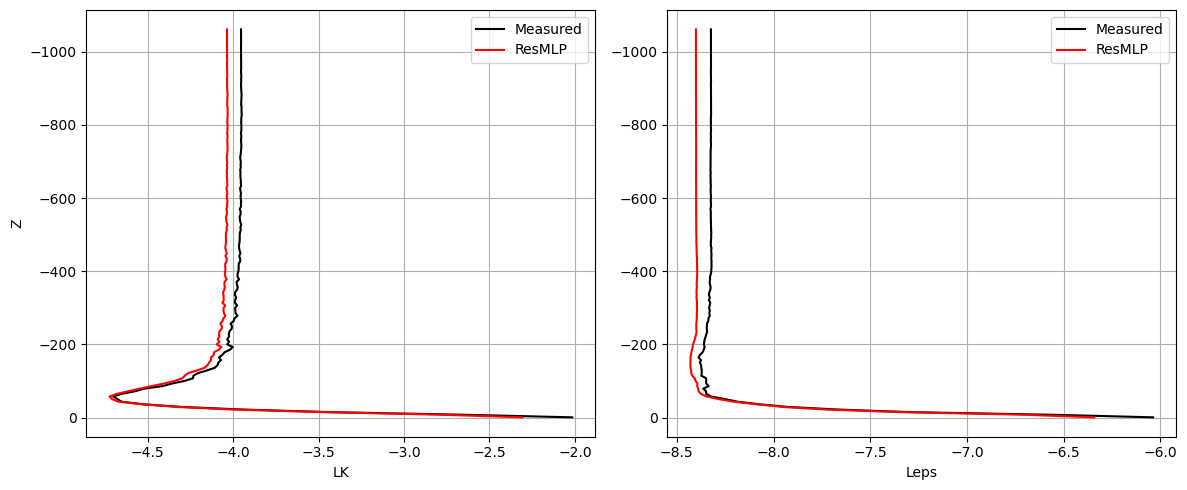

In [14]:
# Advanced model: ResMLP 10-fold ensemble (from prediction script)
advanced_stats = pd.read_csv("./predictions_out/global_stats.csv")

print("ResMLP Ensemble (advanced model):")
print(f"LK RMSE/MAE/R²: {advanced_stats['LK_rmse'].iloc[0]:.3f} / {advanced_stats['LK_mae'].iloc[0]:.3f} / {advanced_stats['LK_r2'].iloc[0]:.3f}")
print(f"Leps RMSE/MAE/R²: {advanced_stats['Leps_rmse'].iloc[0]:.3f} / {advanced_stats['Leps_mae'].iloc[0]:.3f} / {advanced_stats['Leps_r2'].iloc[0]:.3f}")

# Per-profile stats
per_profile = pd.read_csv("./predictions_out/per_profile_stats.csv")
print(f"\nPer-profile avg LK RMSE: {per_profile['LK_rmse'].mean():.3f} ± {per_profile['LK_rmse'].std():.3f}")

# Comparison table vs baseline
comparison = pd.DataFrame({
    "Metric": ["LK RMSE", "LK MAE", "LK R²", "Leps RMSE", "Leps MAE", "Leps R²"],
    "Baseline": [f"{advanced_stats[k].iloc[0]:.3f}" for k in ["LK_rmse", "LK_mae", "LK_r2", 
                                                              "Leps_rmse", "Leps_mae", "Leps_r2"]],
    "ResMLP": [f"{advanced_stats[k].iloc[0]:.3f}" for k in ["LK_rmse", "LK_mae", "LK_r2", 
                                                            "Leps_rmse", "Leps_mae", "Leps_r2"]]
})
print("\nComparison:")
print(comparison.to_markdown(index=False))

# Mean profiles plot
mean_prof = pd.read_csv("./predictions_out/mean_vertical_profiles.csv")
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(mean_prof["LK_meas_mean"], mean_prof["Z_grid"], "k-", label="Measured")
plt.plot(mean_prof["LK_pred_mean"], mean_prof["Z_grid"], "r-", label="ResMLP")
plt.gca().invert_yaxis(); plt.ylabel("Z"); plt.xlabel("LK"); plt.legend(); plt.grid()
plt.subplot(1,2,2)
plt.plot(mean_prof["Leps_meas_mean"], mean_prof["Z_grid"], "k-", label="Measured")
plt.plot(mean_prof["Leps_pred_mean"], mean_prof["Z_grid"], "r-", label="ResMLP")
plt.gca().invert_yaxis(); plt.xlabel("Leps"); plt.legend(); plt.grid()
plt.tight_layout()
plt.show()
